# 07 · Inferencia causal: ¿cuánto afectaron los aranceles de EE.UU. de 2025 a las exportaciones chilenas?

**Fase CRISP-DM:** una segunda iteración del ciclo completo, con una pregunta de negocio nueva (la pregunta 5 del
proyecto): comprensión del negocio (qué medidas hubo y a qué productos afectaron), preparación (panel con ceros
explícitos y clasificación de productos según la normativa de EE.UU.), modelado (diferencias en diferencias) y
evaluación (pretendencias, robustez, placebo y potencia estadística).

### Por qué esta pregunta es distinta a las anteriores
Los notebooks 03 y 04 **predicen**: les basta con que una variable anticipe el resultado, aunque no lo cause.
Aquí la pregunta es **causal**: cuánto cambiaron las exportaciones *por* el arancel, comparado con lo que habría
pasado sin él. Ese contrafactual no se observa nunca, así que hay que construirlo con un grupo de comparación
creíble. No se puede experimentar (nadie asigna aranceles al azar), por lo que se usa un **experimento natural**:
el arancel afectó a un destino (EE.UU.) y no a los otros, en una fecha conocida.

### Cronología de las medidas relevantes para Chile

| Fecha | Medida | Qué cambia para Chile |
|---|---|---|
| 20-ene-2025 | Cambio de gobierno en EE.UU. | Comienzan las amenazas arancelarias: posible **adelanto de embarques** |
| 25-feb-2025 | Investigación Sección 232 al cobre | Arbitraje de precios: el cátodo se desvía hacia EE.UU. |
| 5-abr-2025 | Arancel recíproco (EO 14257) | **10% a casi todo**, salvo el Annex II (cobre, minerales críticos, energía, madera, farmacéuticos) |
| 1-ago-2025 | Sección 232 al cobre (anunciada el 8-jul) | **50% al cobre semielaborado** (alambre, barras, tubos); el cátodo queda exento |
| 7-ago-2025 | Nuevas tasas recíprocas (EO 14326) | Chile sigue en 10%; competidores como Noruega (15%), Nueva Zelanda (15%) y Sudáfrica (30%) suben |
| 8-sep-2025 | Modificación del Annex II (EO 14346) | Entran y salen productos de la lista de exentos |
| 14-oct-2025 | Sección 232 a la madera | 10% a la madera aserrada |
| 13-nov-2025 | Exención agrícola | Parte de los alimentos sale del arancel recíproco |
| 20-feb-2026 | La Corte Suprema anula los aranceles IEEPA | Los reemplaza un 10% transitorio bajo la Sección 122 (24-feb a 24-jul-2026) |

Fuentes: órdenes ejecutivas y proclamaciones de la Casa Blanca y alertas legales, citadas en el Anexo B de `docs/PROYECTO.md`. El detalle del análisis está en su §15.

### Dos diseños, porque los dos aranceles son distintos
1. **Arancel recíproco del 10%:** afectó a más de mil productos, con muchos destinos de comparación. Permite una
   **diferencia en diferencias** con un panel grande.
2. **Sección 232 al cobre semielaborado (50%):** afectó a muy pocos flujos chilenos, casi solo alambre de cobre.
   Se analiza como **estudio de caso**.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from comercio_chile import viz, causal as C
from comercio_chile.data import country_names

viz.setup(); warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pct = lambda b: f"{np.expm1(b) * 100:+.1f}%"
PAISES = country_names()

df = C.panel()
print(f"Panel: {len(df):,} filas = {df[['hs6', 'pais']].drop_duplicates().shape[0]:,} pares producto–destino × {df.periodo.nunique()} meses")
print(f"Celdas con comercio: {(df.valor_usd > 0).mean():.0%} (el resto son ceros explícitos)")

Panel: 848,288 filas = 26,509 pares producto–destino × 32 meses
Celdas con comercio: 27% (el resto son ceros explícitos)


## 1. Preparación: quién recibió el tratamiento

**Unidad de análisis:** exportaciones de bienes de un producto (HS6) a un destino en un mes. El panel incluye los
pares producto–destino con comercio **antes** del arancel (ene-2024 a mar-2025), con **ceros explícitos** en los
meses sin comercio: si un flujo desaparece por el arancel, ese cero es justamente el efecto que se quiere medir.
Elegir la muestra con meses posteriores al arancel la condicionaría al resultado.

**Clasificación de productos** a partir del Annex II oficial (`references/codigos/eeuu_annex_ii_hs6.csv`):
- **Gravado:** paga el 10% en EE.UU. Es el grupo tratado.
- **Exento:** el Annex II cubre la subpartida completa.
- **Exento parcial:** el anexo lista solo algunas aperturas de 8 dígitos de EE.UU. dentro del HS6. No se puede
  saber qué parte del flujo pagó el arancel, así que se excluye.
- **Excluido:** productos con su propio arancel o con una dinámica ajena al arancel recíproco: acero, aluminio
  y automóviles (Sección 232), cobre (Sección 232 desde agosto y arbitraje del cátodo durante la investigación)
  y metales preciosos (dudas arancelarias sobre el oro y cambios en el Annex II).

In [2]:
pre = df[df.eeuu & ~df.post]
resumen = pre.groupby("grupo").agg(productos=("hs6", "nunique"), musd_a_eeuu=("valor_usd", lambda v: v.sum() / 1e6))
resumen["% del valor a EE.UU."] = resumen.musd_a_eeuu / resumen.musd_a_eeuu.sum() * 100
resumen.round(1).sort_values("musd_a_eeuu", ascending=False)

,productos,musd_a_eeuu,% del valor a EE.UU.
grupo,,,
gravado,1379,8758.8,46.1
excluido,132,8230.0,43.3
exento_parcial,35,1135.4,6.0
exento,40,876.9,4.6


El grupo **excluido** pesa mucho en valor porque contiene el cátodo de cobre, el principal producto que Chile
vende a EE.UU. Dejarlo fuera es una decisión deliberada: el cátodo estaba exento del 10%, pero durante la
investigación de la Sección 232 se desvió hacia EE.UU. por una diferencia de precios entre bolsas (sección 7).
Incluirlo mezclaría ese arbitraje con el efecto del arancel recíproco.

## 2. El problema de la comparación ingenua

La forma más simple de "medir el efecto" es comparar las exportaciones gravadas a EE.UU. antes y después.

In [3]:
def change(mask, a, b, c, d):
    x = df[mask]
    before = x[(x.periodo >= pd.Period(a, "M")) & (x.periodo <= pd.Period(b, "M"))].valor_usd.sum()
    after = x[(x.periodo >= pd.Period(c, "M")) & (x.periodo <= pd.Period(d, "M"))].valor_usd.sum()
    return after / before - 1

gravado = df.grupo == "gravado"
us_chg = change(gravado & df.eeuu, "2024-04", "2024-07", "2025-04", "2025-07")
rest_chg = change(gravado & ~df.eeuu, "2024-04", "2024-07", "2025-04", "2025-07")
print(f"Productos gravados, abr–jul 2025 vs abr–jul 2024:  a EE.UU. {us_chg:+.1%}   al resto {rest_chg:+.1%}")
print(f"Diferencia en diferencias agregada: {(1 + us_chg) / (1 + rest_chg) - 1:+.1%}")

Productos gravados, abr–jul 2025 vs abr–jul 2024:  a EE.UU. -2.3%   al resto +6.5%
Diferencia en diferencias agregada: -8.3%


Mirado solo, el antes/después dice que las exportaciones gravadas a EE.UU. casi no cambiaron. Pero en el mismo
período las ventas de esos productos al resto del mundo crecieron, así que "casi no cambiar" puede esconder una
pérdida relativa. Restar ese cambio del resto es la idea de la **diferencia en diferencias**. Este cálculo agregado
todavía tiene dos problemas: mezcla productos con composición distinta en cada destino y no entrega una medida de
incertidumbre. Ambos se resuelven con el modelo de la sección siguiente.

## 3. Diseño: diferencias en diferencias con PPML

$$E[y_{p,c,t}] = \exp\left(\beta \cdot \text{EE.UU.}_c \times \text{post}_t + \alpha_{p,c} + \gamma_{p,t}\right)$$

- $y_{p,c,t}$: valor FOB exportado del producto $p$ al destino $c$ en el mes $t$ (incluye ceros).
- $\alpha_{p,c}$ (**producto × destino**): el nivel habitual de cada flujo. El salmón a EE.UU. y el salmón a
  Brasil tienen escalas distintas, y eso no es efecto del arancel.
- $\gamma_{p,t}$ (**producto × mes**): todo lo que le pasa a un producto en un mes, para todos los destinos a la
  vez: precio internacional, cosecha, estacionalidad, problemas de oferta en Chile.
- $\beta$: lo que queda es cuánto cambió **el destino EE.UU.** frente a los otros destinos del **mismo producto
  en el mismo mes**. El efecto en porcentaje es $e^{\beta} - 1$.

**Por qué PPML (Poisson pseudo-máxima verosimilitud)** y no una regresión sobre el logaritmo:
1. Más del 70% de las celdas son ceros, y el logaritmo de cero no existe. Reemplazarlo por log(1 + y) hace que el
   resultado dependa de la unidad de medida (dólares o millones).
2. Con heterocedasticidad, el coeficiente de una regresión en logaritmos está sesgado (Santos Silva y Tenreyro,
   2006). PPML es consistente con solo especificar bien la media, y es el estándar en la literatura de comercio.
3. Pondera naturalmente por tamaño: el efecto estimado se refiere al **valor** exportado, que es lo que importa
   para el negocio.

**Inferencia:** errores estándar agrupados por producto (HS6), porque los meses de un mismo producto están
correlacionados. Con un solo país tratado, esos errores pueden ser optimistas, así que la sección 6 agrega una
prueba de permutación.

**Ventana principal: abril a julio de 2025.** En esos meses casi todos los proveedores de EE.UU. pagaban el mismo
10%. Desde agosto cambian las reglas (tabla de cronología), y el efecto deja de ser el de un arancel uniforme.

**Supuesto clave (tendencias paralelas):** sin el arancel, la brecha entre lo que Chile vende de un producto a
EE.UU. y lo que vende al resto habría seguido igual. No se puede probar, pero sí contrastar: si la brecha ya se
movía **antes** del arancel, el diseño no es creíble.

## 4. Event study: el contraste de tendencias paralelas

En vez de un solo coeficiente antes/después, se estima uno por mes, relativo a diciembre de 2024 (el último mes
antes del cambio de gobierno en EE.UU.). Los coeficientes de 2024 deberían estar cerca de cero; enero a marzo de
2025 pueden mostrar anticipación; y desde abril aparece el efecto, si existe.

In [4]:
d_full = C.estimation_sample(df, end=df.periodo.max())
es, pretest = C.event_study(d_full)
print(f"Test conjunto de pretendencias (meses de 2024 = 0): estadístico {pretest['estadistico']:.1f}, p = {pretest['p']:.3f}")
es_pct = es.set_index("periodo")[["beta", "ic_inf", "ic_sup"]].apply(lambda c: np.expm1(c) * 100)
es_pct.columns = ["efecto %", "IC 95% inf", "IC 95% sup"]
es_pct.T.round(1)

Test conjunto de pretendencias (meses de 2024 = 0): estadístico 18.0, p = 0.082


periodo,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,...,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08
efecto %,-2.3,16.0,5.8,5.2,2.8,-5.8,14.3,3.9,6.5,-2.2,...,3.7,-2.0,-10.5,-6.5,-8.6,-20.4,-14.6,3.7,0.6,-3.1
IC 95% inf,-18.6,-5.4,-16.4,-10.8,-23.2,-25.1,-6.5,-16.5,-12.3,-19.5,...,-18.5,-22.4,-24.7,-24.7,-25.3,-41.4,-39.3,-22.3,-25.3,-27.3
IC 95% sup,17.2,42.1,33.9,24.0,37.5,18.4,39.7,29.2,29.5,18.8,...,31.9,23.9,6.4,16.2,11.7,8.1,20.0,38.6,35.5,29.0


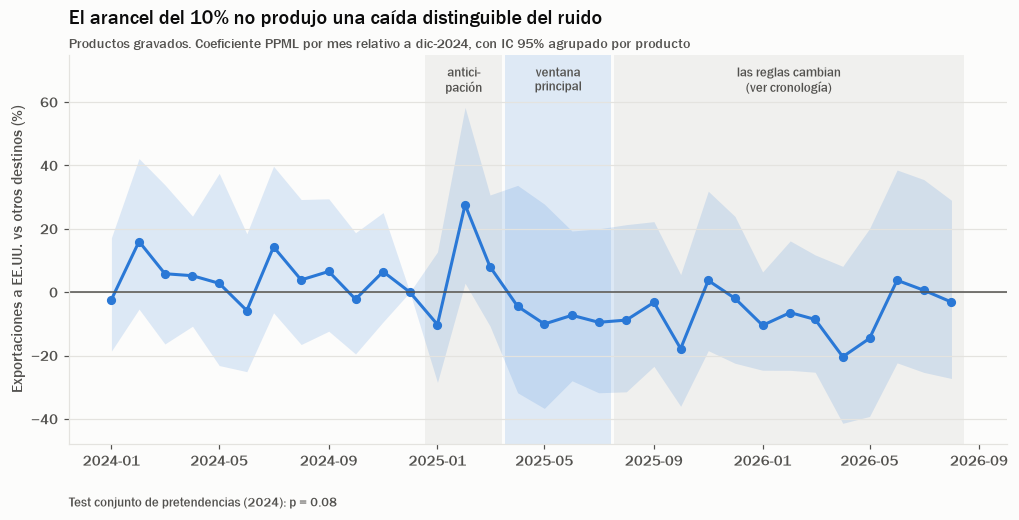

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.6))
x = es.periodo.dt.to_timestamp()
spans = [("2025-01", "2025-03", "antici-\npación", viz.NEUTRAL), ("2025-04", "2025-07", "ventana\nprincipal", viz.SERIES[0]),
         ("2025-08", "2026-08", "las reglas cambian\n(ver cronología)", viz.NEUTRAL)]
for a, b, label, color in spans:
    a_, b_ = pd.Period(a, "M").to_timestamp() - pd.Timedelta(days=14), pd.Period(b, "M").to_timestamp() + pd.Timedelta(days=14)
    ax.axvspan(a_, b_, color=color, alpha=0.10 if color == viz.NEUTRAL else 0.14, lw=0)
    ax.text(a_ + (b_ - a_) / 2, 0.97, label, transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize=8.5, color=viz.TEXT_2)
eff, lo, hi = (np.expm1(es[c]) * 100 for c in ["beta", "ic_inf", "ic_sup"])
ax.fill_between(x, lo, hi, color=viz.EXPORT, alpha=0.15, lw=0)
ax.plot(x, eff, color=viz.EXPORT, marker="o")
ax.axhline(0, color=viz.TEXT_2, lw=1)
ax.set_ylabel("Exportaciones a EE.UU. vs otros destinos (%)")
ax.set_ylim(-48, 75)
ax.set_title("El arancel del 10% no produjo una caída distinguible del ruido")
viz.subtitle(ax, "Productos gravados. Coeficiente PPML por mes relativo a dic-2024, con IC 95% agrupado por producto")
ax.text(0, -0.16, f"Test conjunto de pretendencias (2024): p = {pretest['p']:.2f}", transform=ax.transAxes, fontsize=8.5, color=viz.TEXT_2)
viz.save(fig, "24_arancel_event_study"); fig

**Lectura:**
- **Pretendencias:** los coeficientes de 2024 oscilan entre −6% y +16%, todos con intervalos que incluyen el cero.
  El test conjunto no rechaza al 5% (p = 0,08), aunque sí lo haría con un criterio de 10%. Es un aval débil: con
  intervalos tan anchos el test tiene poca potencia, y "no rechazar" no es lo mismo que "probar" tendencias
  paralelas.
- **Anticipación:** febrero de 2025 muestra un salto de +28%, el único coeficiente significativo de la serie. Es
  compatible con adelantar embarques antes de que llegara el arancel.
- **Abril a julio de 2025:** los cuatro coeficientes son negativos (entre −5% y −10%), pero ninguno es
  significativo por separado. El efecto agregado de la sección 5 es algo mayor (−12,6%) porque compara contra el
  promedio de todo el período previo, que estaba por encima de diciembre de 2024.
- **Desde agosto de 2025** la brecha sigue levemente negativa (entre −20% y +4%), sin ningún mes significativo.
  No se interpreta como efecto causal: ahí cambian las reglas (competidores con aranceles mayores, exenciones
  agrícolas, Sección 122).

### Lo que descarté en el camino: la triple diferencia
El diseño que planeé primero era una **triple diferencia**: agregar los productos exentos del Annex II como
segundo grupo de control, con un efecto fijo destino × mes que absorbería cualquier shock propio de EE.UU. (el
dólar, el ciclo económico). En teoría es más robusta. En la práctica, Chile vende a EE.UU. solo 40 productos
exentos, dominados por embarques grandes e irregulares de madera, yodo y litio, y la brecha gravados–exentos
**ya se movía antes del arancel**: su test de pretendencias rechaza con p ≈ 0,001 (tabla siguiente). Un diseño que
no pasa su propio supuesto no puede ser el principal, aunque en el papel sea más completo. Las dos estimaciones
dan casi el mismo número, así que el cambio de diseño no responde a buscar un resultado.

## 5. Estimación principal y robustez

In [6]:
d = C.estimation_sample(df)
months_q1 = pd.period_range("2025-01", "2025-03", freq="M")
specs = {
    "Principal: abr–jul 2025": (C.did, d),
    "Sin ene–mar 2025 (posible anticipación)": (C.did, d[~d.periodo.isin(months_q1)]),
    "Ventana abr–ago 2025": (C.did, C.estimation_sample(df, end=pd.Period("2025-08", "M"))),
    "Sin filete de salmón (mayor flujo)": (C.did, d[d.hs6 != "030441"]),
    "Sin salmón (partida 0304)": (C.did, d[~d.hs6.str.startswith("0304")]),
    "Triple diferencia (con exentos)": (C.ddd, d),
}
rows = []
for name, (model, data) in specs.items():
    r = model(data).tidy().loc["tratado"]
    rows.append({"especificación": name, "efecto": pct(r.Estimate), "IC 95%": f"[{pct(r['2.5%'])}, {pct(r['97.5%'])}]",
                 "p": round(r["Pr(>|t|)"], 3), "beta": r.Estimate, "se": r["Std. Error"]})
robust = pd.DataFrame(rows).set_index("especificación")
main = robust.iloc[0]
_, ddd_pretest = C.event_study(C.estimation_sample(df, end=C.MAIN_END), triple=True)
print(f"Pretendencias de la triple diferencia: p = {ddd_pretest['p']:.3f}")
robust[["efecto", "IC 95%", "p"]]

Pretendencias de la triple diferencia: p = 0.001


,efecto,IC 95%,p
especificación,,,
Principal: abr–jul 2025,-12.6%,"[-31.5%, +11.4%]",0.275
Sin ene–mar 2025 (posible anticipación),-12.1%,"[-30.1%, +10.5%]",0.268
Ventana abr–ago 2025,-12.6%,"[-30.6%, +10.0%]",0.251
Sin filete de salmón (mayor flujo),-13.6%,"[-32.9%, +11.4%]",0.259
Sin salmón (partida 0304),-21.2%,"[-38.2%, +0.5%]",0.055
Triple diferencia (con exentos),-12.7%,"[-39.3%, +25.4%]",0.461


**Lectura:** todas las especificaciones apuntan a una caída de entre 12% y 21%, y **ninguna es significativa al
5%**. El resultado no depende de la anticipación (quitar enero–marzo no cambia nada), de extender la ventana ni
de un solo producto. Sin el salmón la caída estimada es mayor (−21%, p ≈ 0,06); es una pista de heterogeneidad
por sector, pero no la trato como hallazgo: después de probar varias especificaciones, un p de 0,06 en una de
ellas es justo el tipo de resultado que aparece por azar.

## 6. Inferencia por permutación: placebo en otros destinos

Los errores agrupados suponen muchos grupos tratados, y aquí hay un solo país tratado. Una prueba más honesta es
preguntar: **si le asigno el "arancel" a otro destino que no tuvo ninguno, ¿qué tan grande sale el efecto?** Se
repite la estimación para los 30 principales destinos (sin EE.UU.). Si el efecto de EE.UU. es real, debería quedar
en la cola de esa distribución.

In [7]:
placebo = C.placebo_countries(d)
placebo["nombre"] = placebo.pais.map(PAISES).str.title().str.replace(r" (De|Del) ", lambda m: m.group(0).lower(), regex=True)
b_us = main.beta
p_two = ((placebo.beta.abs() >= abs(b_us)).sum() + 1) / (len(placebo) + 1)
p_one = ((placebo.beta <= b_us).sum() + 1) / (len(placebo) + 1)
print(f"EE.UU.: {pct(b_us)}   p de permutación: dos colas {p_two:.2f}, una cola {p_one:.2f}")
print(f"Placebos: mediana {pct(placebo.beta.median())}, rango {pct(placebo.beta.min())} a {pct(placebo.beta.max())}")

EE.UU.: -12.6%   p de permutación: dos colas 0.52, una cola 0.29
Placebos: mediana +3.8%, rango -50.2% a +35.4%


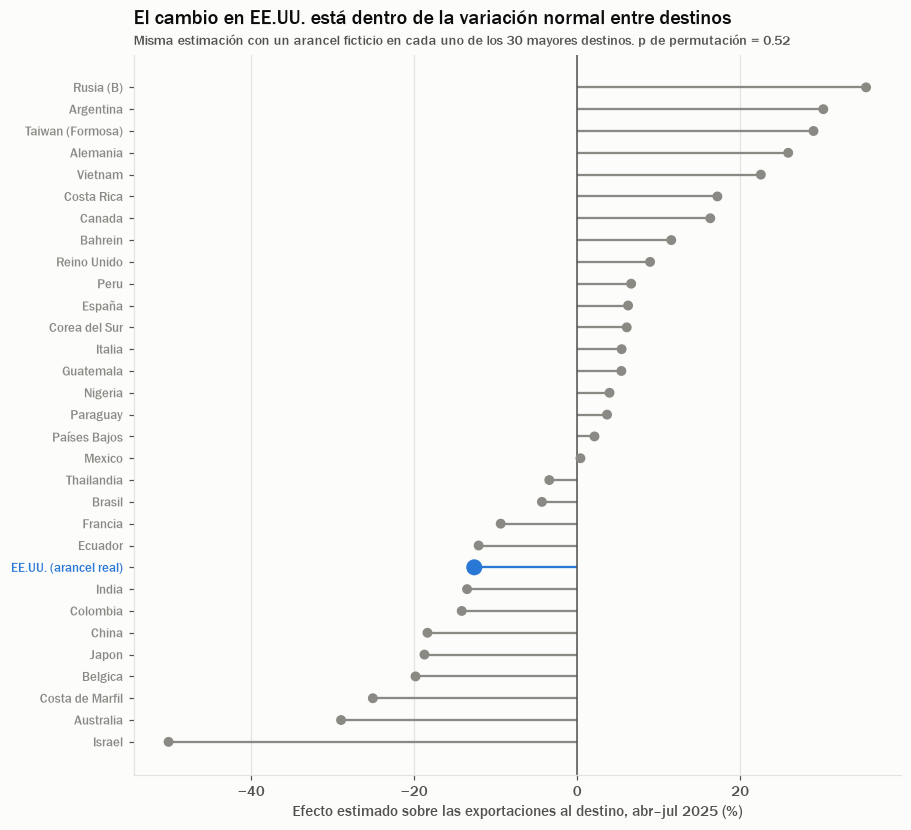

In [8]:
pl = pd.concat([placebo[["nombre", "beta"]], pd.DataFrame({"nombre": ["EE.UU. (arancel real)"], "beta": [b_us]})])
pl = pl.assign(efecto=np.expm1(pl.beta) * 100).sort_values("efecto").reset_index(drop=True)
colors = [viz.EXPORT if n.startswith("EE.UU.") else viz.NEUTRAL for n in pl.nombre]
fig, ax = plt.subplots(figsize=(9, 8.5))
ax.hlines(pl.index, 0, pl.efecto, color=colors, lw=1.5)
ax.scatter(pl.efecto, pl.index, color=colors, s=[90 if c == viz.EXPORT else 30 for c in colors], zorder=3)
ax.set_yticks(pl.index, pl.nombre, fontsize=8.5)
for t, c in zip(ax.get_yticklabels(), colors):
    t.set_color(c)
    t.set_fontweight("bold" if c == viz.EXPORT else "normal")
ax.axvline(0, color=viz.TEXT_2, lw=1)
ax.grid(axis="y", visible=False); ax.grid(axis="x")
ax.set_xlabel("Efecto estimado sobre las exportaciones al destino, abr–jul 2025 (%)")
ax.set_title("El cambio en EE.UU. está dentro de la variación normal entre destinos")
viz.subtitle(ax, f"Misma estimación con un arancel ficticio en cada uno de los 30 mayores destinos. p de permutación = {p_two:.2f}")
viz.save(fig, "25_arancel_placebo"); fig

**Lectura:** la caída estimada para EE.UU. es del mismo tamaño que los cambios que muestran destinos sin ningún
arancel nuevo. Aproximadamente la mitad de los placebos tiene un efecto igual o más extremo, así que la
permutación confirma lo que decían los errores estándar: con estos datos, el efecto del 10% **no se distingue del
ruido normal entre destinos**.

## 7. Potencia: qué efectos se podían detectar

Un resultado no significativo no demuestra que el efecto sea cero. La pregunta correcta es **qué tamaño de efecto
habría podido detectar este diseño**. El efecto mínimo detectable (MDE) con 80% de potencia y 5% de significancia
es aproximadamente 2,8 errores estándar.

In [9]:
mde = -2.8 * main.se
print(f"Error estándar del efecto principal: {main.se:.3f}  ->  efecto mínimo detectable ≈ {pct(mde)}")

Error estándar del efecto principal: 0.124  ->  efecto mínimo detectable ≈ -29.3%


**Lectura:** el diseño solo podía detectar caídas de alrededor de 30% o más. Una caída de 10%, que es lo que
sugiere la estimación puntual, quedaba fuera de su alcance. La conclusión correcta no es "el arancel no tuvo
efecto", sino **"el efecto, si existió, fue menor a ~30% en los primeros cuatro meses, y el punto estimado está
cerca de −12%"**.

### Por qué un efecto pequeño es económicamente plausible
- **El arancel fue casi universal.** Entre abril y julio de 2025 casi todos los proveedores de EE.UU. pagaban el
  mismo 10%. El comprador estadounidense no tenía un proveedor más barato al cual cambiarse (salvo productores
  locales o de México y Canadá bajo el T-MEC), así que el efecto depende solo de cuánto cae la demanda total con un
  precio 10% más alto.
- **Ventana corta.** Cuatro meses alcanzan para ver reacciones inmediatas, no la reorganización de contratos y
  cadenas de suministro, que toma más tiempo.
- **Valor FOB.** Los datos de Aduana registran el precio en origen. Si el importador absorbe el arancel, el valor
  FOB no cambia aunque el consumidor final pague más.

## 8. Estudio de caso: el arancel del 50% al cobre semielaborado

La Sección 232 gravó con 50% el cobre semielaborado desde el 1 de agosto de 2025 (anunciado el 8 de julio). Chile
exporta poco de estos productos, casi todo alambre de cobre (7408), así que no hay un panel grande para una
diferencia en diferencias. Pero el corte es nítido y hay una comparación natural: el mismo alambre vendido a
otros destinos. Aquí se mide en **toneladas**, porque el precio del cobre subió fuerte en 2026 y en dólares un
aumento de precio se confundiría con más volumen (la misma trampa del EDA, sección 5).

In [10]:
cu = C.copper_semis()
before = cu.index < pd.Period("2025-08", "M")
rows = {}
for col, name in [("toneladas_eeuu", "a EE.UU."), ("toneladas_resto", "al resto"), ("total", "total")]:
    s = cu.toneladas_eeuu + cu.toneladas_resto if col == "total" else cu[col]
    diff, ci = C.block_bootstrap_diff(s[before].values, s[~before].values)
    rows[name] = {"antes (t/mes)": s[before].mean(), "después (t/mes)": s[~before].mean(), "cambio (t/mes)": diff,
                  "IC 95% inf": ci[0], "IC 95% sup": ci[1], "cambio %": diff / s[before].mean() * 100}
copper = pd.DataFrame(rows).T
print("Antes: ene-2024 a jul-2025 (19 meses). Después: ago-2025 a ago-2026 (13 meses). IC por bootstrap de bloques de 3 meses.")
copper.round(0)

Antes: ene-2024 a jul-2025 (19 meses). Después: ago-2025 a ago-2026 (13 meses). IC por bootstrap de bloques de 3 meses.


,antes (t/mes),después (t/mes),cambio (t/mes),IC 95% inf,IC 95% sup,cambio %
a EE.UU.,720.0,58.0,-661.0,-819.0,-503.0,-92.0
al resto,2898.0,2701.0,-197.0,-763.0,615.0,-7.0
total,3617.0,2759.0,-858.0,-1471.0,25.0,-24.0


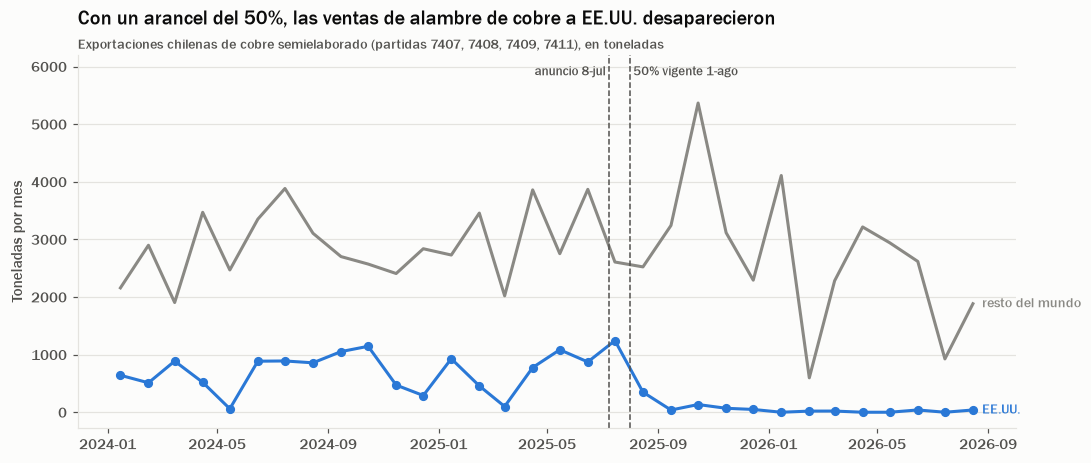

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.4))
x = cu.index.to_timestamp() + pd.Timedelta(days=14)   # cada mes en su punto medio, para ubicarlo bien respecto de las fechas
ax.plot(x, cu.toneladas_resto, color=viz.NEUTRAL, label="al resto del mundo")
ax.plot(x, cu.toneladas_eeuu, color=viz.EXPORT, marker="o", label="a EE.UU.")
for date, label, ha in [("2025-07-08", "anuncio 8-jul ", "right"), ("2025-08-01", " 50% vigente 1-ago", "left")]:
    ax.axvline(pd.Timestamp(date), color=viz.TEXT_2, lw=1, ls="--")
    ax.text(pd.Timestamp(date), 0.97, label, transform=ax.get_xaxis_transform(), ha=ha, va="top", fontsize=8.5, color=viz.TEXT_2)
viz.label_end(ax, x[-1], cu.toneladas_resto.iloc[-1], "resto del mundo", viz.NEUTRAL)
viz.label_end(ax, x[-1], cu.toneladas_eeuu.iloc[-1], "EE.UU.", viz.EXPORT)
ax.set_ylabel("Toneladas por mes")
ax.set_ylim(top=6200)
ax.set_title("Con un arancel del 50%, las ventas de alambre de cobre a EE.UU. desaparecieron")
viz.subtitle(ax, "Exportaciones chilenas de cobre semielaborado (partidas 7407, 7408, 7409, 7411), en toneladas")
viz.save(fig, "26_cobre_semielaborado"); fig

**Lectura:**
- **Efecto directo:** las ventas a EE.UU. cayeron **más de 90%**, de ~720 a ~60 toneladas por mes, con un
  intervalo de confianza muy lejos de cero. A diferencia del 10%, un 50% sobre el contenido de cobre hace
  inviable el negocio.
- **Anticipación:** julio de 2025, entre el anuncio y la entrada en vigencia, fue el mes con más toneladas a
  EE.UU. de toda la serie: se adelantaron embarques para llegar antes del 1 de agosto.
- **Desvío de comercio:** las ventas al resto del mundo no subieron para compensar (el cambio estimado es
  negativo y su intervalo incluye el cero). Hasta donde muestran los datos, el volumen perdido en EE.UU. no se
  recolocó en otros mercados, y el total exportado cayó cerca de 24%, aunque ese intervalo roza el cero.
- **Sobre el diseño:** es una comparación antes/después de una sola serie, con el resto del mundo como referencia,
  no un panel grande. Lo sostiene la nitidez del corte (una caída de 90% justo en la fecha de vigencia) más que
  la sofisticación del modelo. Un control sintético agregaría poco aquí: sirve cuando el efecto es moderado y no
  hay una comparación evidente, y en este caso pasa lo contrario.

## 9. Limitaciones
- **Un solo país tratado.** Toda la inferencia del arancel recíproco descansa en una comparación con un único
  EE.UU. La permutación lo aborda, pero 30 placebos dan una distribución gruesa.
- **Tendencias paralelas no demostradas.** El test no rechaza, pero con poca potencia. La triple diferencia, que
  habría controlado los shocks propios de EE.UU., no pasó su propio contraste.
- **Desvío de comercio y SUTVA.** Si el arancel hizo que Chile vendiera más a otros destinos, el grupo de control
  también quedó afectado y la diferencia en diferencias sobrestima la caída en EE.UU. En el caso del cobre no hay
  evidencia de desvío; en el arancel recíproco no se puede separar.
- **Valor FOB, no incidencia.** Los datos no muestran quién pagó el arancel ni el precio final en EE.UU.
- **Ventana corta y reglas cambiantes.** El efecto de mediano plazo no se puede aislar después de julio de 2025.
- **Clasificación aproximada.** El Annex II está en 8 dígitos de EE.UU. y los datos en 6 dígitos del Sistema
  Armonizado; los casos ambiguos se excluyeron en vez de adivinarse.

## 10. Conclusiones
1. **Arancel recíproco del 10%:** la estimación puntual es una caída de alrededor de 12% en las exportaciones
   gravadas a EE.UU. durante abril–julio de 2025, pero no es estadísticamente distinguible de cero (IC 95% de
   −32% a +11%, p de permutación ≈ 0,5). El diseño podía detectar caídas de ~30% o más, así que se puede descartar
   un efecto grande e inmediato, no uno moderado.
2. **Sección 232 al cobre (50%):** efecto inequívoco. Las ventas de cobre semielaborado a EE.UU. cayeron más de
   90%, sin evidencia de que el volumen se haya recolocado en otros mercados.
3. **La dosis importa:** un 10% compartido por casi todos los competidores casi no se nota en los datos; un 50%
   específico elimina el flujo.
4. **Lección metodológica:** el diseño más completo en el papel (triple diferencia) no siempre es el mejor. Lo
   que decide es si su supuesto se sostiene en los datos, y eso se revisa antes de mirar el resultado.